# PyFC: Optimizer Strategy Comparison, and Custom Plotting from Disk

PyFC offers four `strategy` choices for both the data fit and the Monte Carlo toy fits:

* **`"scipy"`** (L-BFGS-B): gradient-based, very fast, assumes a reasonably smooth
  likelihood surface. The default, and usually the right first choice.
* **`"grid"`**: brute-force scan over the provided parameter nodes. Always finds *a* grid
  point's worth of precision, never gets stuck in a local minimum, but scales poorly past
  a couple of parameters and its precision is capped by the grid resolution itself.
* **`"hybrid"`**: UltraNest for the one-time global unconditional fit, `"scipy"` for the
  (many) conditional fits during profiling and toy generation -- a balance of UltraNest's
  robustness where it matters most and SciPy's speed everywhere else.
* **`"ultranest"`**: nested sampling throughout. Most robust against multi-modal surfaces,
  but by far the slowest -- included below only if the optional `ultranest` package is
  installed.

We compare all of them on the same small model, then reuse the `"scipy"` run's saved
`.json`/`.npz` output to build a fully custom Matplotlib contour (rather than relying on
PyFC's own `generate_corner_plot`), to demonstrate the file formats documented in the
README's *Outputs, Plots, and Checkpointing* section.

In [1]:
%matplotlib inline

import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from numba import njit

from pyfc.orchestrator import compute_fc_intervals
from pyfc.optimizers import ULTRANEST_AVAILABLE

np.random.seed(20260727)

N_TOYS = 15
CORES = 2

Numba detected: JIT compilation enabled for maximum speed.


## 1. Comparing strategies

A 3-parameter binned model: a signal normalization, a background normalization, and one flat
"systematic" nuisance parameter. `compute_2D_intervals=True` so every strategy also produces
the pairwise `.npz`/`.json` files we reuse in Part 2 (using the `"scipy"` run specifically).

In [2]:
S_template = np.array([0.1, 0.5, 2.0, 5.0])
B_template = np.array([15.0, 5.0, 1.0, 0.1])
observed_counts = np.array([20, 7, 2, 0])
ZERO_SUMW2 = np.zeros_like(observed_counts).astype(float)


@njit(fastmath=True, nogil=True)
def compute_rates(params, S_sumw2, B_sumw2):
    # params[0] = S_norm, params[1] = B_norm, params[2] = sys_1 (flat shift, weakly constrained)
    mu = params[0] * S_template + params[1] * B_template + params[2] * 0.05
    return mu, np.zeros_like(mu)


grids = [np.linspace(0.5, 1.5, 8) for _ in range(3)]
param_names = ["S_norm", "B_norm", "sys_1"]

strategies = ["grid", "scipy"]
if ULTRANEST_AVAILABLE:
    # "hybrid" also uses ultranest internally for the one-time global fit,
    # so it needs the same availability guard as the pure "ultranest" strategy.
    strategies += ["hybrid", "ultranest"]
else:
    print("(ultranest not installed -- skipping the \"hybrid\" and \"ultranest\" strategies)")

print("--- Strategy comparison: 3-parameter binned model ---")
for strat in strategies:
    t0 = time.time()
    _, fig = compute_fc_intervals(
        data=observed_counts, grids=grids, compute_rates_func=compute_rates,
        S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
        likelihood_type="binned", strategy=strat,
        cl=[0.90], n_toys=N_TOYS, num_cores=CORES, verbose=0,
        compute_1D_intervals=True, compute_2D_intervals=True,
        sparsify_grid=(strat == "grid"),   # grid strategy needs it most; see the algorithmic-features notebook
        param_names=param_names,
        output_file="fc_results", save_directory=f"strategy_comparison_output/{strat}",
    )
    elapsed = time.time() - t0
    if fig is not None:
        plt.close(fig)   # suppress inline rendering of the built-in corner plot for each strategy

    with open(f"strategy_comparison_output/{strat}/fc_results.json") as f:
        saved = json.load(f)
    bounds = saved["1d_intervals"]["param1"]["thresholds"]["0.9"]["interval_bounds"]
    print(f"{strat:>10}: {elapsed:6.2f}s | S_norm 90% CL bounds: {bounds}")

(ultranest not installed -- skipping the "hybrid" and "ultranest" strategies)
--- Strategy comparison: 3-parameter binned model ---


      grid:   3.46s | S_norm 90% CL bounds: [0.5, 0.5]


     scipy:  13.08s | S_norm 90% CL bounds: [0.5, 0.5]


## 2. Custom plotting directly from the saved `.json`/`.npz` files

PyFC's built-in `generate_corner_plot` covers the common case, but for a publication figure
you'll usually want full control. This cell ingests the `"scipy"` run's output exactly as a
downstream analysis script would -- scalar metadata (best fit, 1D bounds) from the `.json`,
and the 2D grid/acceptance arrays from the `.npz` -- with no dependency on PyFC's plotting
module at all.

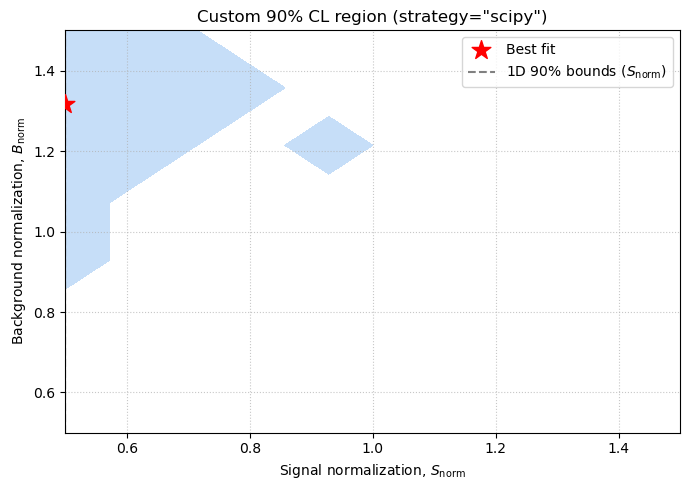

In [3]:
base_dir = "strategy_comparison_output/scipy"

with open(os.path.join(base_dir, "fc_results.json")) as f:
    fc_data = json.load(f)
best_fit = fc_data["best_fit"]
s_norm_bounds_90 = fc_data["1d_intervals"]["param1"]["thresholds"]["0.9"]["interval_bounds"]

npz_data = np.load(os.path.join(base_dir, "fc_results.npz"))
p1_vals = npz_data["2d_test_p1_p1p2"]
p2_vals = npz_data["2d_test_p2_p1p2"]
accepted_mask_90 = npz_data["2d_accepted_p1p2_0.9"]
X, Y = np.meshgrid(p1_vals, p2_vals, indexing="ij")

fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(X, Y, accepted_mask_90, levels=[0.5, 1.5], colors=["#a1c9f4"], alpha=0.6)
ax.scatter(best_fit[0], best_fit[1], color="red", marker="*", s=200, zorder=5, label="Best fit")
ax.axvline(s_norm_bounds_90[0], color="gray", linestyle="--", linewidth=1.5, label="1D 90% bounds ($S_{\\rm norm}$)")
ax.axvline(s_norm_bounds_90[1], color="gray", linestyle="--", linewidth=1.5)
ax.set_xlabel(r"Signal normalization, $S_{\rm norm}$")
ax.set_ylabel(r"Background normalization, $B_{\rm norm}$")
ax.set_title("Custom 90% CL region (strategy=\"scipy\")")
ax.legend(loc="upper right")
ax.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

## Next steps

* `pyfc_quickstart_tutorial.ipynb` -- the basic binned/unbinned workflow.
* `pyfc_high_dimensional_tutorial.ipynb` -- scaling to many parameters.
* `pyfc_algorithmic_features_tutorial.ipynb` -- the `sparsify_grid`/`smooth_*`/finite-MC knobs.
* `pyfc_joint_constraints_tutorial.ipynb` -- joint/simplex parameter constraints.